# EIA 930 FROM vs TO Consistency

Two questions:

1. **Direct overlap** — for flows between two CA-8 BAs (e.g. BANC→CISO), the row appears in *both* the `from-` and `to-` files.  Are the values identical?
2. **Cross-file misreporting** — for every flow `A→B` in FROM, there should be a corresponding `B→A` entry in TO whose value is the exact negative.  How often do they disagree, and which BAs are responsible?

The 8 California balancing authorities: BANC, CISO, IID, LDWP, NEVP, PACW, TIDC, WALC

---
**Note on date alignment**: The FROM and TO files were scraped at slightly different times and may
have different end dates.  Both are trimmed to the earlier endpoint before analysis so every flow
has a symmetric counterpart.

In [47]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

ROOT = Path().resolve().parent
RAW  = ROOT / 'data' / 'raw' / 'eia'

CA8 = frozenset({'BANC', 'CISO', 'IID', 'LDWP', 'NEVP', 'PACW', 'TIDC', 'WALC'})

print('Loading FROM files ...')
from_df = pd.concat(
    [pd.read_csv(p) for p in sorted(RAW.glob('*_from-*'))], ignore_index=True
)
print(f'  {len(from_df):,} rows  [{from_df["period"].min()} – {from_df["period"].max()}]')

print('Loading TO files ...')
to_df = pd.concat(
    [pd.read_csv(p) for p in sorted(RAW.glob('*_to-*'))], ignore_index=True
)
print(f'  {len(to_df):,} rows  [{to_df["period"].min()} – {to_df["period"].max()}]')

# Trim both to the earlier endpoint
cutoff = min(from_df['period'].max(), to_df['period'].max())
print(f'\nTrimming both to cutoff: {cutoff}')
from_df = from_df[from_df['period'] <= cutoff]
to_df   = to_df  [to_df  ['period'] <= cutoff]
print(f'  FROM: {len(from_df):,} rows')
print(f'  TO:   {len(to_df):,} rows')

Loading FROM files ...
  3,062,327 rows  [2019-01-01T00 – 2026-05-29T07]
Loading TO files ...
  2,990,439 rows  [2019-01-01T00 – 2026-05-30T07]

Trimming both to cutoff: 2026-05-29T07
  FROM: 3,062,327 rows
  TO:   2,989,455 rows


## Part 1 — Direct overlap: same (period, fromba, toba) in both files

When both ends of an interchange are CA-8 BAs (e.g. BANC→CISO), the row appears in the FROM file
(because BANC ∈ CA8) **and** in the TO file (because CISO ∈ CA8).  Inner-joining on
`(period, fromba, toba)` finds all such duplicate rows.  We expect 100% identical values because
EIA stores one measurement for each (period, fromba, toba) pair — the same record populates both
endpoints' query results.

In [48]:
from_inter = from_df[from_df['toba'].isin(CA8)]
to_inter   = to_df  [to_df  ['fromba'].isin(CA8)]

print(f'FROM rows where toba   in CA8: {len(from_inter):,}')
print(f'TO   rows where fromba in CA8: {len(to_inter):,}')

merged = from_inter.merge(
    to_inter[['period', 'fromba', 'toba', 'value']],
    on=['period', 'fromba', 'toba'],
    suffixes=('_from', '_to'),
    how='inner',
)
print(f'\nInner-join hits: {len(merged):,}')

identical = (merged['value_from'] == merged['value_to']).sum()
diff      = (merged['value_from'] != merged['value_to']).sum()
print(f'  Identical values : {identical:,}  ({100*identical/len(merged):.3f}%)')
print(f'  Different values : {diff:,}')
if diff:
    print()
    print('  Sample of different rows:')
    print(merged[merged['value_from'] != merged['value_to']].head(5).to_string())

FROM rows where toba   in CA8: 1,547,017
TO   rows where fromba in CA8: 1,547,017

Inner-join hits: 1,547,017
  Identical values : 1,547,017  (100.000%)
  Different values : 0


## Part 2 — Cross-file misreporting: does A's export to B equal B's import from A?

The correct consistency check is:

- FROM file has `A→B` with value `X` (BA **A** self-reports it exported `X` MWh to **B**)
- TO file has `B→A` with value `Y` (BA **B** self-reports it exported `Y` MWh to **A**, which should be `−X` if they agree)

`delta = X + Y` should be 0.  Non-zero delta means the two endpoints reported different magnitudes
for the same physical flow.

This cross-join includes **all** tracked flows (not just inter-CA-8 pairs), covering both:
- **Inter-8**: BANC↔CISO, where both sides are CA BAs (both report to FROM and TO files)
- **External**: BANC↔BPAT, where BPAT only appears in the TO file as fromba

---
**Why this differs from a within-FROM self-join**: An earlier version of this notebook joined
FROM with itself (comparing `from[A→B]` with `from[B→A]`).  That approach is equivalent for
inter-8 pairs (since FROM and TO have identical values for the same row), but it misses all
external-BA flows entirely.  External BAs only appear in the TO file; their cross-direction
counterpart is only accessible by joining FROM with TO.  The self-join also inflated the mismatch
rate to ~19% by looking only at inter-8 pairs, which happen to have the highest disagreement rates.

In [49]:
# Cross-join: match from[A->B] with to[B->A]
# delta = from[A->B].value + to[B->A].value  (should be 0)
foo = pd.merge(
    from_df, to_df,
    how='inner',
    left_on =['period', 'fromba', 'toba'],
    right_on=['period', 'toba',   'fromba'],
)
foo['delta'] = foo['value_x'] + foo['value_y']

n_total   = len(foo)
n_mismatch = (foo['delta'].abs() > 1).sum()
print(f'Cross-join rows:          {n_total:,}')
print(f'|delta| > 1 MWh:          {n_mismatch:,}  ({100*n_mismatch/n_total:.2f}%)')
print(f'|delta| > 100 MWh:        {(foo.delta.abs()>100).sum():,}')
print(f'|delta| > 1000 MWh:       {(foo.delta.abs()>1000).sum():,}')
print()

# Break down by flow type
foo_inter8   = foo[ foo['fromba_x'].isin(CA8) &  foo['fromba_y'].isin(CA8)]
foo_external = foo[~(foo['fromba_x'].isin(CA8) & foo['fromba_y'].isin(CA8))]
print(f'Inter-8 rows: {len(foo_inter8):,}   |delta|>1: {(foo_inter8.delta.abs()>1).sum():,}  ({100*(foo_inter8.delta.abs()>1).mean():.1f}%)')
print(f'External rows:{len(foo_external):,} |delta|>1: {(foo_external.delta.abs()>1).sum():,} ({100*(foo_external.delta.abs()>1).mean():.1f}%)')
print()
print('delta statistics (all rows):')
print(foo['delta'].describe())

Cross-join rows:          2,969,968
|delta| > 1 MWh:          375,746  (12.65%)
|delta| > 100 MWh:        129,822
|delta| > 1000 MWh:       1,258

Inter-8 rows: 1,536,026   |delta|>1: 213,650  (13.9%)
External rows:1,433,942 |delta|>1: 162,096 (11.3%)

delta statistics (all rows):
count    2.969968e+06
mean     1.191545e+02
std      1.203372e+04
min     -9.830300e+04
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.295304e+06
Name: delta, dtype: float64


In [63]:
sym.sort_values('delta',ascending=False)

,period,fromba,fromba-name,toba,toba-name,value,value-units,value_rev,delta
116938,2019-07-25T04,BANC,Balancing Authority of Northern California,CISO,California Independent System Operator,3295697,megawatthours,-393,3295304
116940,2019-07-25T04,CISO,California Independent System Operator,BANC,Balancing Authority of Northern California,-393,megawatthours,3295697,3295304
77338,2019-05-17T01,TIDC,Turlock Irrigation District,BANC,Balancing Authority of Northern California,191,megawatthours,2233277,2233468
77321,2019-05-17T01,BANC,Balancing Authority of Northern California,TIDC,Turlock Irrigation District,2233277,megawatthours,191,2233468
70330,2019-05-04T21,TIDC,Turlock Irrigation District,BANC,Balancing Authority of Northern California,294,megawatthours,2201716,2202010
...,...,...,...,...,...,...,...,...,...
59546,2019-04-16T04,CISO,California Independent System Operator,LDWP,Los Angeles Department of Water and Power,-3333,megawatthours,-541,-3874
1532596,2026-05-23T01,CISO,California Independent System Operator,BANC,Balancing Authority of Northern California,274,megawatthours,-6606,-6332
1532594,2026-05-23T01,BANC,Balancing Authority of Northern California,CISO,California Independent System Operator,-6606,megawatthours,274,-6332
69882,2019-05-04T03,CISO,California Independent System Operator,BANC,Balancing Authority of Northern California,-1324,megawatthours,-66834,-68158


In [50]:
# Worst offenders — sort by |delta| to see the most egregious misreports
foo_mismatch = foo[foo['delta'].abs() > 1].copy()
foo_mismatch['abs_delta'] = foo_mismatch['delta'].abs()

print('Top 10 rows by |delta|:')
cols = ['period', 'fromba_x', 'toba_x', 'value_x', 'fromba_y', 'toba_y', 'value_y', 'delta']
print(foo_mismatch.nlargest(10, 'abs_delta')[cols].to_string(index=False))

Top 10 rows by |delta|:
       period fromba_x toba_x  value_x fromba_y toba_y  value_y   delta
2019-07-25T04     BANC   CISO  3295697     CISO   BANC     -393 3295304
2019-07-25T04     CISO   BANC     -393     BANC   CISO  3295697 3295304
2019-05-17T01     BANC   TIDC  2233277     TIDC   BANC      191 2233468
2019-05-17T01     TIDC   BANC      191     BANC   TIDC  2233277 2233468
2019-05-04T21     BANC   TIDC  2201716     TIDC   BANC      294 2202010
2019-05-04T21     TIDC   BANC      294     BANC   TIDC  2201716 2202010
2019-05-04T23     BANC   TIDC  2201770     TIDC   BANC      240 2202010
2019-05-04T23     TIDC   BANC      240     BANC   TIDC  2201770 2202010
2019-05-05T00     BANC   TIDC  2201864     TIDC   BANC      146 2202010
2019-05-05T00     TIDC   BANC      146     BANC   TIDC  2201864 2202010


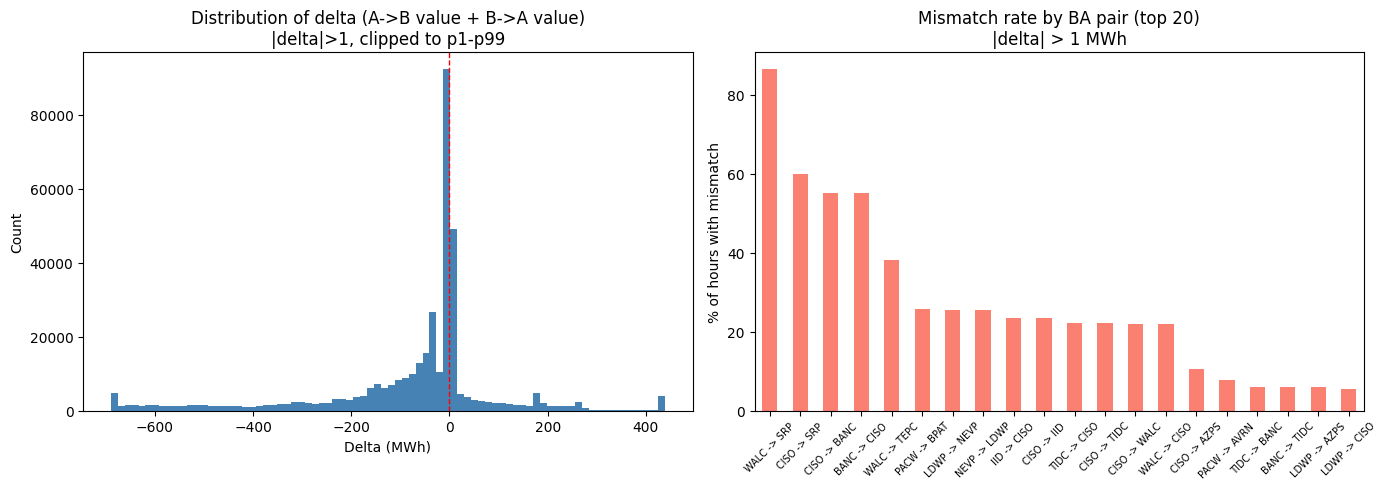

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of deltas (|delta| > 1, clipped p1-p99)
nonzero = foo_mismatch['delta']
lo, hi = np.percentile(nonzero, [1, 99])
axes[0].hist(nonzero.clip(lo, hi), bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Distribution of delta (A->B value + B->A value)\n|delta|>1, clipped to p1-p99')
axes[0].set_xlabel('Delta (MWh)')
axes[0].set_ylabel('Count')
axes[0].axvline(0, color='red', lw=1, ls='--')

# Mismatch rate per BA pair (fromba_x -> toba_x)
pair_stats = (
    foo
    .assign(pair=foo['fromba_x'] + ' -> ' + foo['toba_x'],
            mismatch=(foo['delta'].abs() > 1).astype(int))
    .groupby('pair')['mismatch']
    .agg(rate='mean', count='size')
    .sort_values('rate', ascending=False)
    .head(20)
)
pair_stats['rate_pct'] = pair_stats['rate'] * 100
pair_stats['rate_pct'].plot(kind='bar', ax=axes[1], color='salmon', edgecolor='none')
axes[1].set_title('Mismatch rate by BA pair (top 20)\n|delta| > 1 MWh')
axes[1].set_ylabel('% of hours with mismatch')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', labelsize=7, rotation=45)

plt.tight_layout()
plt.show()

## Part 3 — Monthly mismatch count: total and per BA

If a BA changed its reporting process at some point (e.g. switched sign convention, changed
measurement interval), we would see a step-change in its mismatch count.  `fromba_x` identifies
the CA BA on the FROM side of each flow; a spike in one BA's line points to that BA as the source.

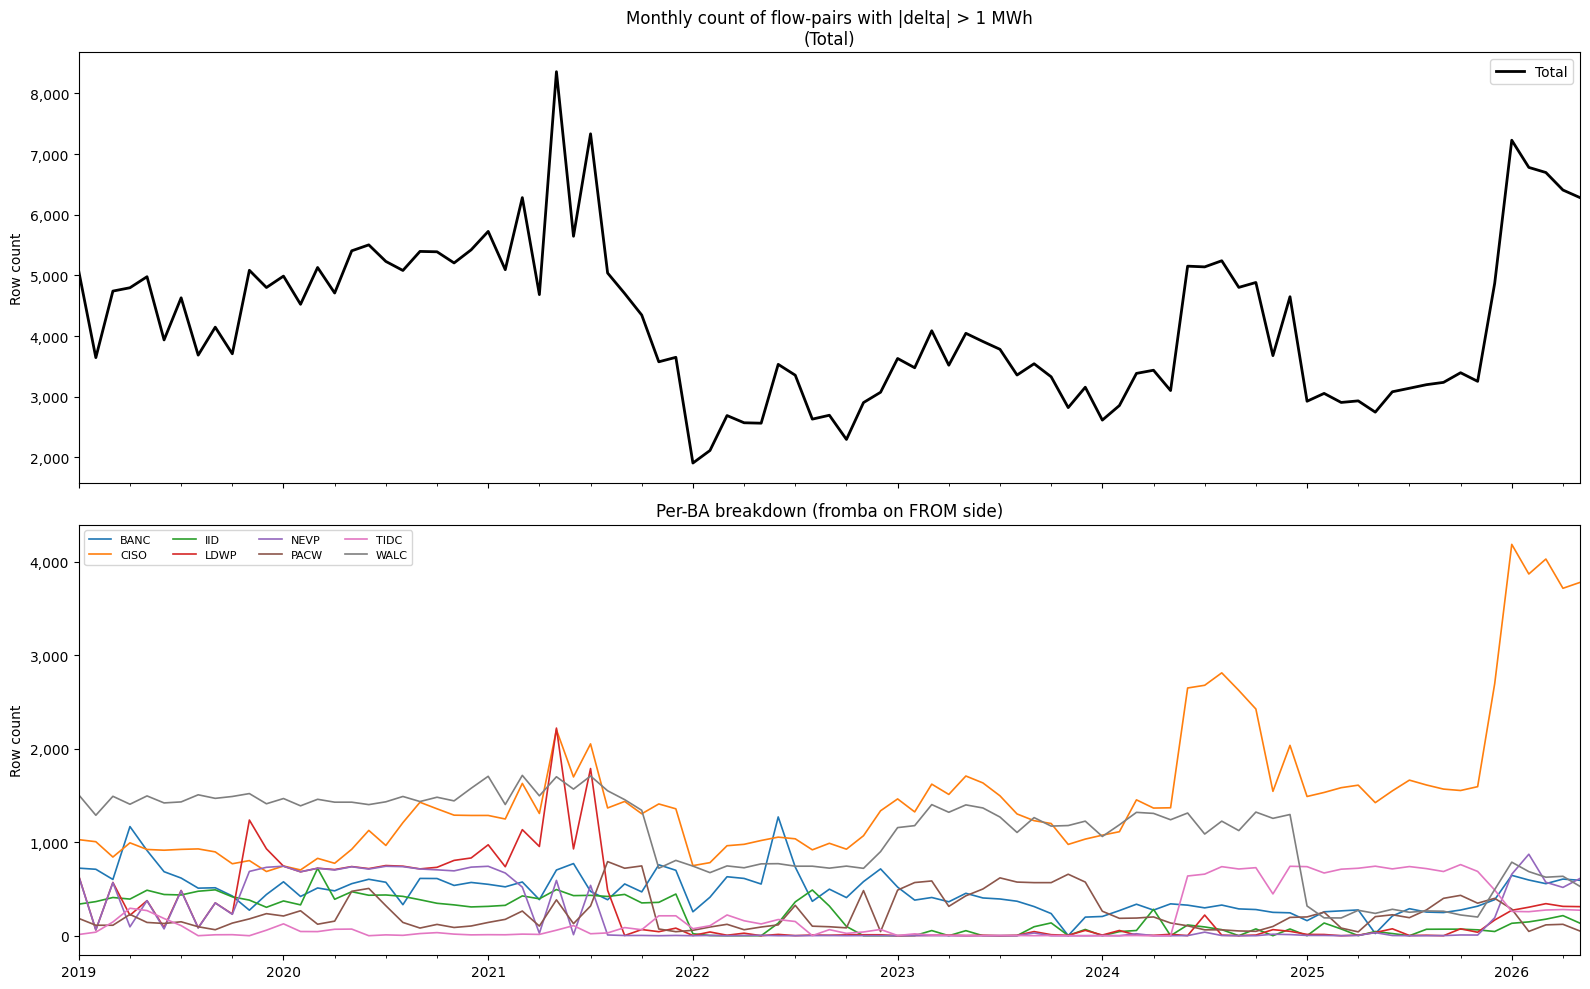

In [52]:
mismatch = foo[foo['delta'].abs() > 1].copy()
mismatch['month'] = pd.to_datetime(mismatch['period'].str[:7])

# Total monthly mismatch count
monthly_total = mismatch.groupby('month').size().rename('Total')

# Per-BA monthly mismatch count (fromba_x = CA BA on FROM side)
monthly_ba = (
    mismatch
    .groupby(['month', 'fromba_x'])
    .size()
    .unstack(fill_value=0)
)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Top chart: total
monthly_total.plot(ax=axes[0], color='black', lw=2)
axes[0].set_title('Monthly count of flow-pairs with |delta| > 1 MWh\n(Total)')
axes[0].set_ylabel('Row count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend()

# Bottom chart: per BA
ba_cols = sorted(monthly_ba.columns)
colors  = plt.cm.tab10.colors
for i, ba in enumerate(ba_cols):
    monthly_ba[ba].plot(ax=axes[1], label=ba, color=colors[i % len(colors)], lw=1.2)

axes[1].set_title('Per-BA breakdown (fromba on FROM side)')
axes[1].set_ylabel('Row count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(loc='upper left', ncol=4, fontsize=8)
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [53]:
# Print the per-BA monthly table for further inspection
print('Monthly mismatch counts per BA (fromba_x):')
print(monthly_ba.tail(24).to_string())

Monthly mismatch counts per BA (fromba_x):
fromba_x    BANC  CISO  IID  LDWP  NEVP  PACW  TIDC  WALC
month                                                    
2024-06-01   327  2651  115     1     1   106   639  1313
2024-07-01   298  2680   94   221    38    63   659  1088
2024-08-01   328  2813   65     6     2    63   739  1226
2024-09-01   287  2625    0     1     0    51   714  1125
2024-10-01   280  2426   73     7     0    47   728  1323
2024-11-01   250  1545    0    65    16    99   447  1256
2024-12-01   245  2037   72    47    12   196   743  1297
2025-01-01   161  1490    0    14     3   201   739   318
2025-02-01   256  1533  136    13     3   252   671   191
2025-03-01   266  1584   72     0     0    82   712   190
2025-04-01   276  1611    1     6     3    41   722   272
2025-05-01    23  1424   45    34    33   204   744   239
2025-06-01   211  1550   23    74     2   224   715   283
2025-07-01   289  1665    0     2     0   193   740   251
2025-08-01   253  1613   69  

In [54]:
# Top 10 BA pairs by mean |delta|
top_pairs = (
    foo_mismatch
    .assign(pair=foo_mismatch['fromba_x'] + ' -> ' + foo_mismatch['toba_x'])
    .groupby('pair')['abs_delta']
    .agg(mean_abs_delta='mean', count='size')
    .sort_values('mean_abs_delta', ascending=False)
    .head(10)
)
print('Top 10 BA pairs by mean |delta| (MWh):')
print(top_pairs.to_string())

Top 10 BA pairs by mean |delta| (MWh):
              mean_abs_delta  count
pair                               
BANC -> TIDC    49394.751512   3803
TIDC -> BANC    49394.751512   3803
CISO -> AZPS      363.191181   6826
WALC -> GRIF      329.040816     49
PACW -> AVRN      308.036327   4432
CISO -> SRP       289.372108  38685
CISO -> TIDC      289.279684  14284
TIDC -> CISO      289.279684  14284
WALC -> NEVP      246.339286     56
NEVP -> WALC      246.339286     56


In [55]:
# Summary: mismatch count by fromba_x (CA BA on FROM side)
print('Mismatch counts by fromba_x:')
print(
    mismatch
    .groupby('fromba_x')
    .size()
    .sort_values(ascending=False)
    .to_string()
)

Mismatch counts by fromba_x:
fromba_x
CISO    132634
WALC     97316
BANC     41295
LDWP     26264
PACW     21654
NEVP     19745
IID      18751
TIDC     18087


---
# CHECK HERE
*(User's exploratory cells below — preserved as-is)*

In [56]:
from_df.head()

,period,fromba,fromba-name,toba,toba-name,value,value-units
0,2019-01-01T00,BANC,Balancing Authority of Northern California,BPAT,Bonneville Power Administration,-436,megawatthours
1,2019-01-01T00,BANC,Balancing Authority of Northern California,CISO,California Independent System Operator,76,megawatthours
2,2019-01-01T00,BANC,Balancing Authority of Northern California,TIDC,Turlock Irrigation District,-146,megawatthours
3,2019-01-01T00,CISO,California Independent System Operator,AZPS,Arizona Public Service Company,-1371,megawatthours
4,2019-01-01T00,CISO,California Independent System Operator,BANC,Balancing Authority of Northern California,-76,megawatthours


In [57]:
to_df.head()

,period,fromba,fromba-name,toba,toba-name,value,value-units
0,2019-01-01T00,AVA,Avista Corporation,PACW,PacifiCorp West,-9,megawatthours
1,2019-01-01T00,AZPS,Arizona Public Service Company,CISO,California Independent System Operator,1371,megawatthours
2,2019-01-01T00,AZPS,Arizona Public Service Company,IID,Imperial Irrigation District,-13,megawatthours
3,2019-01-01T00,AZPS,Arizona Public Service Company,LDWP,Los Angeles Department of Water and Power,758,megawatthours
4,2019-01-01T00,AZPS,Arizona Public Service Company,WALC,Western Area Power Administration - Desert Sou...,1259,megawatthours


In [58]:
foo2 = pd.merge(left = from_df,right=to_df,how='inner',left_on=['period','fromba','toba'],right_on=['period','toba','fromba'])

In [59]:
foo2['delta'] = foo2['value_x'] + foo2['value_y']
foo2.head()

,period,fromba_x,fromba-name_x,toba_x,toba-name_x,value_x,value-units_x,fromba_y,fromba-name_y,toba_y,toba-name_y,value_y,value-units_y,delta
0,2019-01-01T00,BANC,Balancing Authority of Northern California,BPAT,Bonneville Power Administration,-436,megawatthours,BPAT,Bonneville Power Administration,BANC,Balancing Authority of Northern California,436,megawatthours,0
1,2019-01-01T00,BANC,Balancing Authority of Northern California,CISO,California Independent System Operator,76,megawatthours,CISO,California Independent System Operator,BANC,Balancing Authority of Northern California,-76,megawatthours,0
2,2019-01-01T00,BANC,Balancing Authority of Northern California,TIDC,Turlock Irrigation District,-146,megawatthours,TIDC,Turlock Irrigation District,BANC,Balancing Authority of Northern California,146,megawatthours,0
3,2019-01-01T00,CISO,California Independent System Operator,AZPS,Arizona Public Service Company,-1371,megawatthours,AZPS,Arizona Public Service Company,CISO,California Independent System Operator,1371,megawatthours,0
4,2019-01-01T00,CISO,California Independent System Operator,BANC,Balancing Authority of Northern California,-76,megawatthours,BANC,Balancing Authority of Northern California,CISO,California Independent System Operator,76,megawatthours,0


In [60]:
foo2.loc[(foo2['period']=='2019-07-25T04')&(foo2['fromba_x']=='BANC')&(foo2['toba_x']=='CISO')]

,period,fromba_x,fromba-name_x,toba_x,toba-name_x,value_x,value-units_x,fromba_y,fromba-name_y,toba_y,toba-name_y,value_y,value-units_y,delta
224386,2019-07-25T04,BANC,Balancing Authority of Northern California,CISO,California Independent System Operator,3295697,megawatthours,CISO,California Independent System Operator,BANC,Balancing Authority of Northern California,-393,megawatthours,3295304


In [61]:
foo2.loc[(foo2['period']=='2019-07-25T04')&(foo2['toba_x']=='BANC')&(foo2['toba_y']=='CISO')]

,period,fromba_x,fromba-name_x,toba_x,toba-name_x,value_x,value-units_x,fromba_y,fromba-name_y,toba_y,toba-name_y,value_y,value-units_y,delta
224389,2019-07-25T04,CISO,California Independent System Operator,BANC,Balancing Authority of Northern California,-393,megawatthours,BANC,Balancing Authority of Northern California,CISO,California Independent System Operator,3295697,megawatthours,3295304


In [62]:
len(foo2.loc[foo2['delta']>1e-3])/len(foo2)

0.050118385113913685